# Brasileirão: probabilidades de resultado (A / D / H)

Notebook único, executável do início ao fim, que gera **todas** as submissões enviadas ao Kaggle
(`submissions/`) e o registro de experimentos (`experimentos.csv`).

**Pergunta:** para cada partida do Brasileirão, quais as probabilidades de vitória do visitante (`A`), empate (`D`) e vitória do mandante (`H`)?
**Métrica:** LogLoss multiclasse (`sklearn.metrics.log_loss`, `labels=['A','D','H']`); menor é melhor.

## Regras seguidas
- Somente Python, NumPy, Pandas e Scikit-learn na modelagem.
- Uma previsão de teste usa apenas **a própria linha** de `test.csv` e informação de `train.csv`. Nenhuma linha do teste é cruzada com outra.
- `odd_casa`, `odd_empate` e `odd_visitante` **não** entram em nenhum modelo (não existem no teste).
- Validação *walk-forward* por temporada (treina no passado, valida no futuro), sem embaralhar. Imputação, escala e codificação são ajustadas dentro de cada `Pipeline`, só no treino de cada fold.
- Sementes fixas (`RANDOM_STATE = 42`).

## Linha do tempo das submissões

| Versão | Arquivo | Modelo |
|---|---|---|
| v01 | `submission_28_09.csv` | Regressão logística, 17 variáveis numéricas, `C=1` |
| v02 | `submission_29_09.csv` | Mesmo modelo, `C` ajustado |
| v03 | `submission2_29_09.csv` | Só `elo_diff` |
| v04 | `submission3_29_09.csv` | `elo_diff` + `venue_form_diff` + `form_pts_away` |
| v05 | `submission_30_09.csv` | v04 + `Home`/`Away` (one-hot) |
| final | `submission2_30_09.csv` | Blend 0,5·v04 + 0,5·v05 |

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)

DATA = Path('data')
SUB_DIR = Path('submissions')
SUB_DIR.mkdir(exist_ok=True)
LOG_PATH = Path('experimentos.csv')

CLASS_ORDER = ['A', 'D', 'H']          # ordem alfabética, sempre
RANDOM_STATE = 42
FOLDS = [2016, 2017, 2018, 2019, 2020, 2021]   # treino = temporadas anteriores à do fold

train = pd.read_csv(DATA / 'train.csv')
test = pd.read_csv(DATA / 'test.csv')
print(train.shape, test.shape)
train.head()

(3419, 26) (1725, 22)


,Id,Season,Date,Home,Away,elo_home,elo_away,elo_diff,form_pts_home,form_pts_away,...,rest_days_home,rest_days_away,season_ppg_home,season_ppg_away,round_n,h2h_home_pts,Res,odd_casa,odd_empate,odd_visitante
0,0,2013,2013-05-25,Vasco,Portuguesa,1506.636452,1486.580590,20.055862,1.6,1.0,...,174.0,174.0,NaN,NaN,1,3.0,H,1.86,3.44,4.06
1,1,2013,2013-05-25,Vitoria,Internacional,1500.000000,1490.971962,9.028038,NaN,0.2,...,NaN,174.0,NaN,NaN,1,NaN,D,2.72,3.17,2.52
2,2,2013,2013-05-26,Corinthians,Botafogo RJ,1527.354763,1506.560479,20.794285,2.0,1.0,...,175.0,176.0,NaN,NaN,1,0.0,D,1.82,3.43,4.21
3,3,2013,2013-05-26,Criciuma,Bahia,1500.000000,1498.594997,1.405003,NaN,2.0,...,NaN,175.0,NaN,NaN,1,NaN,H,1.72,3.50,4.70
4,4,2013,2013-05-26,Gremio,Nautico,1561.732962,1489.510755,72.222206,2.2,1.4,...,175.0,175.0,NaN,NaN,1,3.0,H,1.38,4.36,8.19


## 1. Inspeção e alvo

`Res` tem três valores: `H`, `D`, `A`. O `log_loss` do scikit-learn ordena as classes alfabeticamente (`A`, `D`, `H`); todas as saídas abaixo são alinhadas explicitamente a essa ordem via `classes_`, nunca por suposição.

In [2]:
print('Temporadas treino:', train.Season.min(), '-', train.Season.max(), '| teste:', test.Season.min(), '-', test.Season.max())
print('Colunas ausentes no teste:', sorted(set(train.columns) - set(test.columns)))
print('\nProporção de Res por temporada:')
print(pd.crosstab(train.Season, train.Res, normalize='index').round(3))
print('\nNaN por coluna (treino, só colunas com ausência):')
na = train.isna().sum()
print(na[na > 0])

Temporadas treino: 2013 - 2021 | teste: 2022 - 2026
Colunas ausentes no teste: ['Res', 'odd_casa', 'odd_empate', 'odd_visitante']

Proporção de Res por temporada:
Res         A      D      H
Season                     
2013    0.232  0.284  0.484
2014    0.239  0.242  0.518
2015    0.234  0.239  0.526
2016    0.219  0.248  0.533
2017    0.289  0.271  0.439
2018    0.179  0.289  0.532
2019    0.258  0.258  0.484
2020    0.266  0.284  0.450
2021    0.245  0.297  0.458

NaN por coluna (treino, só colunas com ausência):
form_pts_home             7
form_pts_away             9
form_gf_home              7
form_ga_home              7
form_gf_away              9
form_ga_away              9
home_form_as_host        16
away_form_as_visitor     16
rest_days_home            7
rest_days_away            9
season_ppg_home          90
season_ppg_away          90
h2h_home_pts            656
dtype: int64


## 2. Funções comuns

Features derivadas são funções puras de colunas **da mesma linha** (sem parâmetros aprendidos, portanto sem risco de vazamento).

In [3]:
NUM_17 = ['elo_home', 'elo_away', 'elo_diff', 'form_pts_home', 'form_pts_away',
          'form_gf_home', 'form_ga_home', 'form_gf_away', 'form_ga_away',
          'home_form_as_host', 'away_form_as_visitor', 'rest_days_home',
          'rest_days_away', 'season_ppg_home', 'season_ppg_away', 'round_n', 'h2h_home_pts']


def add_features(df):
    out = df.copy()
    out['venue_form_diff'] = out['home_form_as_host'] - out['away_form_as_visitor']
    out['form_pts_diff'] = out['form_pts_home'] - out['form_pts_away']
    out['gd_diff'] = (out['form_gf_home'] - out['form_ga_home']) - (out['form_gf_away'] - out['form_ga_away'])
    return out


train = add_features(train)
test = add_features(test)


def make_logreg(num_cols, cat_cols=(), C=1.0):
    transformers = [('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                                      ('scale', StandardScaler())]), list(num_cols))]
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), list(cat_cols)))
    return Pipeline([('prep', ColumnTransformer(transformers)),
                     ('model', LogisticRegression(C=C, max_iter=5000, random_state=RANDOM_STATE))])


def predict_ordered(model, X):
    """predict_proba alinhado a ['A','D','H'] pelas classes do estimador."""
    raw = pd.DataFrame(model.predict_proba(X), columns=model.named_steps['model'].classes_)
    return raw.reindex(columns=CLASS_ORDER, fill_value=0.0).values


def walk_forward(build, cols):
    """Previsões out-of-fold por temporada; o modelo é reconstruído do zero em cada fold."""
    preds, ys = {}, {}
    for season in FOLDS:
        tr, va = train[train.Season < season], train[train.Season == season]
        model = build()
        model.fit(tr[cols], tr['Res'])
        preds[season] = predict_ordered(model, va[cols])
        ys[season] = va['Res'].values
    return preds, ys


def summarize(preds, ys, name, verbose=True):
    df = pd.DataFrame([{'Season': s, 'n': len(ys[s]), 'LogLoss': log_loss(ys[s], preds[s], labels=CLASS_ORDER)}
                       for s in FOLDS])
    mean = np.average(df['LogLoss'], weights=df['n'])
    if verbose:
        print(f'{name:<38} média ponderada = {mean:.4f} | desvio entre folds = {df.LogLoss.std():.4f}')
    return df, mean


def save_submission(proba, path):
    sub = pd.DataFrame(proba, columns=CLASS_ORDER)
    sub.insert(0, 'Id', test['Id'].values)
    assert list(sub.columns) == ['Id', 'A', 'D', 'H']
    assert len(sub) == len(test) and (sub['Id'].values == test['Id'].values).all()
    vals = sub[CLASS_ORDER].values
    assert np.isfinite(vals).all() and (vals > 0).all()
    assert np.allclose(vals.sum(axis=1), 1.0, atol=1e-9)
    sub.to_csv(path, index=False)
    print('salvo:', path, sub.shape)
    return sub


LOG_ROWS = []


def log_experiment(version, date, change, features, model_desc, params, folds_df, mean, decision, csv_path):
    LOG_ROWS.append({
        'versao': version, 'data': date, 'mudanca': change, 'features': features,
        'modelo': model_desc, 'parametros': params, 'folds': ','.join(map(str, FOLDS)),
        'logloss_por_fold': ';'.join(f'{s}:{v:.4f}' for s, v in zip(folds_df.Season, folds_df.LogLoss)),
        'logloss_medio': round(mean, 4), 'desvio': round(folds_df.LogLoss.std(), 4),
        'decisao': decision, 'csv': csv_path})
    pd.DataFrame(LOG_ROWS).to_csv(LOG_PATH, index=False)

## 3. Baseline sem modelo

Frequência histórica das classes, recalculada em cada fold só com o passado (`DummyClassifier(strategy='prior')`).

In [4]:
def build_prior():
    return Pipeline([('model', DummyClassifier(strategy='prior'))])

p_prior, ys = walk_forward(build_prior, ['elo_diff'])
prior_df, prior_mean = summarize(p_prior, ys, 'Baseline: frequência histórica')
prior_df.round(4)

Baseline: frequência histórica         média ponderada = 1.0517 | desvio entre folds = 0.0307


,Season,n,LogLoss
0,2016,379,1.0150
1,2017,380,1.0874
2,2018,380,1.0148
3,2019,380,1.0520
4,2020,380,1.0747
5,2021,380,1.0663


## 4. v01: regressão logística com as 17 variáveis numéricas (`C=1`)

Primeira submissão: pipeline válido de ponta a ponta. Imputação pela mediana e padronização dentro do `Pipeline`.

In [5]:
p_v01, _ = walk_forward(lambda: make_logreg(NUM_17, C=1.0), NUM_17)
v01_df, v01_mean = summarize(p_v01, ys, 'v01: logreg 17 numéricas, C=1')

final_v01 = make_logreg(NUM_17, C=1.0).fit(train[NUM_17], train['Res'])
save_submission(predict_ordered(final_v01, test[NUM_17]), SUB_DIR / 'submission_28_09.csv')
log_experiment('v01', '2026-09-28', 'baseline logreg', '17 numericas', 'LogisticRegression', 'C=1',
               v01_df, v01_mean, 'campeao inicial', 'submissions/submission_28_09.csv')

v01: logreg 17 numéricas, C=1          média ponderada = 1.0337 | desvio entre folds = 0.0455
salvo: submissions\submission_28_09.csv (1725, 4)


## 5. v02: regularização (única mudança: `C`)

Poucas partidas por temporada e variáveis muito correlacionadas (Elo, forma, pontos) sugerem que regularizar mais reduz a confiança excessiva. `C` é escolhido pela média da validação temporal.

In [6]:
res_C = {}
for C in [1, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001]:
    preds, _ = walk_forward(lambda: make_logreg(NUM_17, C=C), NUM_17)
    res_C[C] = summarize(preds, ys, f'17 numéricas, C={C}')
best_C = min(res_C, key=lambda c: res_C[c][1])
print('melhor C:', best_C)

17 numéricas, C=1                      média ponderada = 1.0337 | desvio entre folds = 0.0455


17 numéricas, C=0.3                    média ponderada = 1.0334 | desvio entre folds = 0.0454


17 numéricas, C=0.1                    média ponderada = 1.0328 | desvio entre folds = 0.0452


17 numéricas, C=0.03                   média ponderada = 1.0312 | desvio entre folds = 0.0444


17 numéricas, C=0.01                   média ponderada = 1.0291 | desvio entre folds = 0.0429


17 numéricas, C=0.003                  média ponderada = 1.0273 | desvio entre folds = 0.0403


17 numéricas, C=0.001                  média ponderada = 1.0282 | desvio entre folds = 0.0372
melhor C: 0.003


In [7]:
assert best_C == 0.003
v02_df, v02_mean = res_C[best_C]
final_v02 = make_logreg(NUM_17, C=best_C).fit(train[NUM_17], train['Res'])
save_submission(predict_ordered(final_v02, test[NUM_17]), SUB_DIR / 'submission_29_09.csv')
log_experiment('v02', '2026-09-29', 'ajuste de C', '17 numericas', 'LogisticRegression', f'C={best_C}',
               v02_df, v02_mean, 'promovido', 'submissions/submission_29_09.csv')

salvo: submissions\submission_29_09.csv (1725, 4)


## 6. v03: modelos de árvore e seleção de variáveis

Duas perguntas com os mesmos folds: (1) árvores superam a logística? (2) O Elo sozinho resume a informação das 17 variáveis?

In [8]:
def build_hgb():
    return Pipeline([('prep', SimpleImputer(strategy='median')),
                     ('model', HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=150,
                                                              l2_regularization=1.0, random_state=RANDOM_STATE))])

def build_rf():
    return Pipeline([('prep', SimpleImputer(strategy='median')),
                     ('model', RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                                      random_state=RANDOM_STATE, n_jobs=-1))])

out03 = {}
for name, build, cols in [('HistGradientBoosting (17)', build_hgb, NUM_17),
                          ('RandomForest (17)', build_rf, NUM_17)]:
    preds, _ = walk_forward(build, cols)
    out03[name] = summarize(preds, ys, name)
for C in [0.3, 0.1, 0.03]:
    preds, _ = walk_forward(lambda: make_logreg(['elo_diff'], C=C), ['elo_diff'])
    out03[f'logreg elo_diff C={C}'] = summarize(preds, ys, f'logreg elo_diff, C={C}')

HistGradientBoosting (17)              média ponderada = 1.0486 | desvio entre folds = 0.0528


RandomForest (17)                      média ponderada = 1.0323 | desvio entre folds = 0.0401


logreg elo_diff, C=0.3                 média ponderada = 1.0228 | desvio entre folds = 0.0416
logreg elo_diff, C=0.1                 média ponderada = 1.0228 | desvio entre folds = 0.0414


logreg elo_diff, C=0.03                média ponderada = 1.0229 | desvio entre folds = 0.0408


In [9]:
key = 'logreg elo_diff C=0.1'
v03_df, v03_mean = out03[key]
final_v03 = make_logreg(['elo_diff'], C=0.1).fit(train[['elo_diff']], train['Res'])
save_submission(predict_ordered(final_v03, test[['elo_diff']]), SUB_DIR / 'submission2_29_09.csv')
log_experiment('v03', '2026-09-29', 'selecao: so elo_diff (arvores rejeitadas)', 'elo_diff', 'LogisticRegression', 'C=0.1',
               v03_df, v03_mean, 'promovido', 'submissions/submission2_29_09.csv')

salvo: submissions\submission2_29_09.csv (1725, 4)


## 7. v04: features derivadas da própria linha

Partindo de `elo_diff`, adiciono **uma variável por vez** (todas calculadas na mesma linha) e depois combino as que melhoram.

In [10]:
base_df, base_mean = v03_df, v03_mean
rows = []
for extra in ['venue_form_diff', 'form_pts_diff', 'gd_diff', 'form_pts_away', 'form_pts_home',
              'h2h_home_pts', 'rest_days_home', 'season_ppg_home', 'round_n']:
    cols = ['elo_diff', extra]
    preds, _ = walk_forward(lambda: make_logreg(cols, C=0.1), cols)
    df, m = summarize(preds, ys, f'elo_diff + {extra}', verbose=False)
    rows.append({'extra': extra, 'media': m, 'folds_melhores_que_v03': int((df.LogLoss.values < base_df.LogLoss.values).sum())})
pd.DataFrame(rows).sort_values('media').round(4)

,extra,media,folds_melhores_que_v03
3,form_pts_away,1.0226,3
0,venue_form_diff,1.0226,3
7,season_ppg_home,1.0229,2
5,h2h_home_pts,1.0232,2
1,form_pts_diff,1.0233,3
8,round_n,1.0235,1
4,form_pts_home,1.0235,2
6,rest_days_home,1.0241,3
2,gd_diff,1.0241,1


In [11]:
combos = {'elo+venue': ['elo_diff', 'venue_form_diff'],
          'elo+venue+fpa': ['elo_diff', 'venue_form_diff', 'form_pts_away'],
          'elo+venue+fpa+h2h': ['elo_diff', 'venue_form_diff', 'form_pts_away', 'h2h_home_pts']}
res04 = {}
for name, cols in combos.items():
    for C in [0.3, 0.1, 0.03]:
        preds, _ = walk_forward(lambda: make_logreg(cols, C=C), cols)
        res04[(name, C)] = summarize(preds, ys, f'{name}, C={C}')

elo+venue, C=0.3                       média ponderada = 1.0227 | desvio entre folds = 0.0420


elo+venue, C=0.1                       média ponderada = 1.0226 | desvio entre folds = 0.0417
elo+venue, C=0.03                      média ponderada = 1.0225 | desvio entre folds = 0.0408


elo+venue+fpa, C=0.3                   média ponderada = 1.0224 | desvio entre folds = 0.0410


elo+venue+fpa, C=0.1                   média ponderada = 1.0223 | desvio entre folds = 0.0408


elo+venue+fpa, C=0.03                  média ponderada = 1.0222 | desvio entre folds = 0.0402


elo+venue+fpa+h2h, C=0.3               média ponderada = 1.0228 | desvio entre folds = 0.0413


elo+venue+fpa+h2h, C=0.1               média ponderada = 1.0227 | desvio entre folds = 0.0411


elo+venue+fpa+h2h, C=0.03              média ponderada = 1.0226 | desvio entre folds = 0.0404


In [12]:
NUM = combos['elo+venue+fpa']
v04_df, v04_mean = res04[('elo+venue+fpa', 0.03)]
final_v04 = make_logreg(NUM, C=0.03).fit(train[NUM], train['Res'])
save_submission(predict_ordered(final_v04, test[NUM]), SUB_DIR / 'submission3_29_09.csv')
log_experiment('v04', '2026-09-29', '+venue_form_diff +form_pts_away', ','.join(NUM), 'LogisticRegression', 'C=0.03',
               v04_df, v04_mean, 'promovido', 'submissions/submission3_29_09.csv')

salvo: submissions\submission3_29_09.csv (1725, 4)


## 8. v05: times como variável categórica

Mudança única: `Home` e `Away` com `OneHotEncoder(handle_unknown='ignore')`, ajustado só no treino de cada fold (times novos ficam com vetor zerado). Os one-hots adicionam muitos coeficientes, então testo regularização mais forte.

In [13]:
CAT = ['Home', 'Away']
res05 = {}
for C in [0.03, 0.01, 0.003]:
    preds, _ = walk_forward(lambda: make_logreg(NUM, CAT, C=C), NUM + CAT)
    res05[C] = summarize(preds, ys, f'v04 + times, C={C}')
best_C05 = min(res05, key=lambda c: res05[c][1])
print('melhor C:', best_C05)
pd.DataFrame({'v04': v04_df.LogLoss.values, f'v05 C={best_C05}': res05[best_C05][0].LogLoss.values}, index=FOLDS).round(4)

v04 + times, C=0.03                    média ponderada = 1.0229 | desvio entre folds = 0.0407


v04 + times, C=0.01                    média ponderada = 1.0218 | desvio entre folds = 0.0389


v04 + times, C=0.003                   média ponderada = 1.0245 | desvio entre folds = 0.0363
melhor C: 0.01


,v04,v05 C=0.01
2016,0.9976,0.9978
2017,1.0858,1.0824
2018,0.9808,0.9821
2019,0.9905,0.9904
2020,1.0467,1.0479
2021,1.0320,1.0303


In [14]:
assert best_C05 == 0.01
v05_df, v05_mean = res05[best_C05]
final_v05 = make_logreg(NUM, CAT, C=best_C05).fit(train[NUM + CAT], train['Res'])
save_submission(predict_ordered(final_v05, test[NUM + CAT]), SUB_DIR / 'submission_30_09.csv')
log_experiment('v05', '2026-09-30', '+ Home/Away one-hot', ','.join(NUM + CAT), 'LogisticRegression', f'C={best_C05}',
               v05_df, v05_mean, 'promovido', 'submissions/submission_30_09.csv')

salvo: submissions\submission_30_09.csv (1725, 4)


## 9. Final: blend v04 + v05

v04 e v05 erram de formas diferentes (v05 melhor em 2017/2021, v04 em 2018/2020). Testo uma média ponderada; o peso é escolhido **apenas** nas previsões out-of-fold da validação temporal. A curva é plana entre 0,4 e 0,7; uso `W=0,5` por ser o ponto central, menos dependente de ajuste fino.

In [15]:
p04, _ = walk_forward(lambda: make_logreg(NUM, C=0.03), NUM)
p05, _ = walk_forward(lambda: make_logreg(NUM, CAT, C=0.01), NUM + CAT)

blends = {}
for w in [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    preds = {s: (1 - w) * p04[s] + w * p05[s] for s in FOLDS}
    blends[w] = summarize(preds, ys, f'peso v05 = {w}')

W = 0.5
tab = pd.DataFrame({'v04': blends[0.0][0].LogLoss.values, 'v05': blends[1.0][0].LogLoss.values,
                    'blend 0.5': blends[W][0].LogLoss.values}, index=FOLDS)
tab.loc['média ponderada'] = [blends[0.0][1], blends[1.0][1], blends[W][1]]
tab.round(4)

peso v05 = 0.0                         média ponderada = 1.0222 | desvio entre folds = 0.0402
peso v05 = 0.2                         média ponderada = 1.0220 | desvio entre folds = 0.0399
peso v05 = 0.3                         média ponderada = 1.0219 | desvio entre folds = 0.0397
peso v05 = 0.4                         média ponderada = 1.0218 | desvio entre folds = 0.0396
peso v05 = 0.5                         média ponderada = 1.0218 | desvio entre folds = 0.0395
peso v05 = 0.6                         média ponderada = 1.0218 | desvio entre folds = 0.0394
peso v05 = 0.7                         média ponderada = 1.0218 | desvio entre folds = 0.0392
peso v05 = 0.8                         média ponderada = 1.0218 | desvio entre folds = 0.0391


peso v05 = 1.0                         média ponderada = 1.0218 | desvio entre folds = 0.0389


,v04,v05,blend 0.5
2016,0.9976,0.9978,0.9975
2017,1.0858,1.0824,1.0838
2018,0.9808,0.9821,0.9812
2019,0.9905,0.9904,0.9903
2020,1.0467,1.0479,1.0470
2021,1.0320,1.0303,1.0309
média ponderada,1.0222,1.0218,1.0218


## 10. Calibração (validação temporal)

Probabilidade média prevista vs. frequência observada por faixa, nas previsões out-of-fold do blend.

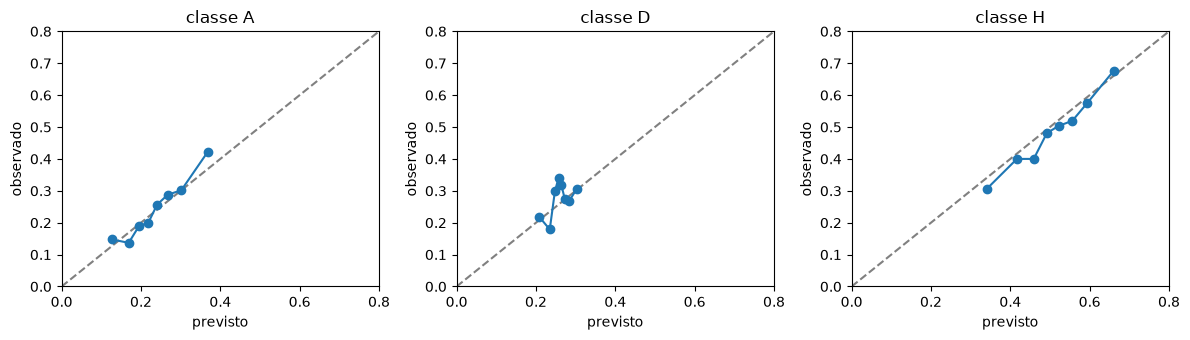

média prevista: [0.236 0.259 0.505] | observada: [np.float64(0.243), np.float64(0.275), np.float64(0.483)]


In [16]:
P = np.vstack([(1 - W) * p04[s] + W * p05[s] for s in FOLDS])
Y = np.concatenate([ys[s] for s in FOLDS])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for i, cls in enumerate(CLASS_ORDER):
    g = pd.DataFrame({'p': P[:, i], 'y': (Y == cls).astype(float)})
    g['faixa'] = pd.qcut(g['p'], 8, duplicates='drop')
    g = g.groupby('faixa', observed=True).mean()
    axes[i].plot([0, 1], [0, 1], '--', color='gray')
    axes[i].plot(g['p'], g['y'], 'o-')
    axes[i].set(title=f'classe {cls}', xlabel='previsto', ylabel='observado', xlim=(0, 0.8), ylim=(0, 0.8))
plt.tight_layout()
plt.show()
print('média prevista:', P.mean(axis=0).round(3), '| observada:', [round((Y == c).mean(), 3) for c in CLASS_ORDER])

## 11. Treino final e submissão final

Os dois modelos são treinados em todo `train.csv`; o peso escolhido na validação é aplicado ao teste.

In [17]:
proba_final = (1 - W) * predict_ordered(final_v04, test[NUM]) + W * predict_ordered(final_v05, test[NUM + CAT])
sub_final = save_submission(proba_final, SUB_DIR / 'submission2_30_09.csv')
log_experiment('final', '2026-09-30', 'blend 0.5*v04 + 0.5*v05', ','.join(NUM + CAT), 'blend de 2 LogisticRegression',
               'v04 C=0.03; v05 C=0.01; W=0.5', blends[W][0], blends[W][1], 'campeao final',
               'submissions/submission2_30_09.csv')
sub_final.describe().round(3)

salvo: submissions\submission2_30_09.csv (1725, 4)


,Id,A,D,H
count,1725.000,1725.000,1725.000,1725.000
mean,4281.000,0.242,0.270,0.489
std,498.109,0.083,0.031,0.107
min,3419.000,0.059,0.153,0.157
25%,3850.000,0.180,0.250,0.412
50%,4281.000,0.234,0.274,0.489
75%,4712.000,0.296,0.292,0.565
max,5143.000,0.571,0.344,0.788


## 12. Resumo dos experimentos

In [18]:
log = pd.read_csv(LOG_PATH)
resumo = pd.concat([pd.DataFrame([{'versao': 'baseline', 'mudanca': 'frequência histórica',
                                   'logloss_medio': round(prior_mean, 4), 'desvio': round(prior_df.LogLoss.std(), 4),
                                   'decisao': 'referência', 'csv': ''}]),
                    log[['versao', 'mudanca', 'logloss_medio', 'desvio', 'decisao', 'csv']]], ignore_index=True)
resumo

,versao,mudanca,logloss_medio,desvio,decisao,csv
0,baseline,frequência histórica,1.0517,0.0307,referência,
1,v01,baseline logreg,1.0337,0.0455,campeao inicial,submissions/submission_28_09.csv
2,v02,ajuste de C,1.0273,0.0403,promovido,submissions/submission_29_09.csv
3,v03,selecao: so elo_diff (arvores rejeitadas),1.0228,0.0414,promovido,submissions/submission2_29_09.csv
4,v04,+venue_form_diff +form_pts_away,1.0222,0.0402,promovido,submissions/submission3_29_09.csv
5,v05,+ Home/Away one-hot,1.0218,0.0389,promovido,submissions/submission_30_09.csv
6,final,blend 0.5*v04 + 0.5*v05,1.0218,0.0395,campeao final,submissions/submission2_30_09.csv


## 13. Diagnóstico das odds (fora de qualquer pipeline de submissão)

As odds existem só no treino. A soma das probabilidades implícitas passa de 1 porque a cotação embute a margem da casa (*overround*). Esta célula é apenas descritiva e não alimenta nenhum modelo.

In [19]:
imp = 1 / train[['odd_casa', 'odd_empate', 'odd_visitante']]
print('soma média das probabilidades implícitas:', imp.sum(axis=1).mean().round(4))

soma média das probabilidades implícitas: 1.0693


## 14. Checagem final de todas as submissões

Formato, ordem dos `Id` e validade das probabilidades em cada CSV gerado.

In [20]:
sample = pd.read_csv(DATA / 'sample_submission.csv')
for f in sorted(SUB_DIR.glob('*.csv')):
    s = pd.read_csv(f)
    assert list(s.columns) == list(sample.columns) == ['Id', 'A', 'D', 'H']
    assert (s['Id'].values == test['Id'].values).all() and len(s) == len(test)
    v = s[CLASS_ORDER].values
    assert np.isfinite(v).all() and (v >= 0).all() and np.allclose(v.sum(axis=1), 1.0)
    print('OK', f.name, s.shape)

OK submission2_29_09.csv (1725, 4)


OK submission2_30_09.csv (1725, 4)
OK submission3_29_09.csv (1725, 4)
OK submission_28_09.csv (1725, 4)


OK submission_29_09.csv (1725, 4)


OK submission_30_09.csv (1725, 4)
